# Tooth Number Detection using YOLO

Goal: Train an object detection model to automatically detect and number teeth from dental X-ray images.

We use YOLO11 for fast and accurate detection.

# Setup & Installations

In [1]:
!pip install ultralytics -q
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import random
import shutil
from collections import Counter
from IPython.display import Image, display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Data Preparation

We download and extract the dataset and verify the directory structure.

In [2]:
!unzip -q /content/ToothNumber_TaskDataset.zip -d /content/ToothNumber_TaskDataset

In [3]:
dataset_path = "/content/ToothNumber_TaskDataset"

images_path = os.path.join(dataset_path, "images")
labels_path = os.path.join(dataset_path, "labels")

In [4]:
train_ratio = 0.8

all_images = []

for f in os.listdir(images_path):
    full = os.path.join(images_path, f)
    if os.path.isfile(full) and f.lower().endswith((".jpg",".jpeg",".png")):
        all_images.append(f)

print("Total images found:", len(all_images))

random.shuffle(all_images)

split_index = int(len(all_images) * train_ratio)

train_files = all_images[:split_index]
val_files = all_images[split_index:]


for split in ["train", "val"]:
    os.makedirs(os.path.join(images_path, split), exist_ok=True)
    os.makedirs(os.path.join(labels_path, split), exist_ok=True)


def copy_files(file_list, split):
    for img_file in file_list:
        label_file = img_file.rsplit(".",1)[0] + ".txt"

        src_img = os.path.join(images_path, img_file)
        src_lbl = os.path.join(labels_path, label_file)

        dst_img = os.path.join(images_path, split, img_file)
        dst_lbl = os.path.join(labels_path, split, label_file)

        shutil.copy(src_img, dst_img)

        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)

copy_files(train_files, "train")
copy_files(val_files, "val")

print("Split Done")
print("Train:", len(train_files))
print("Val:", len(val_files))

Total images found: 497
Split Done
Train: 397
Val: 100


# Visualize Sample Training Images

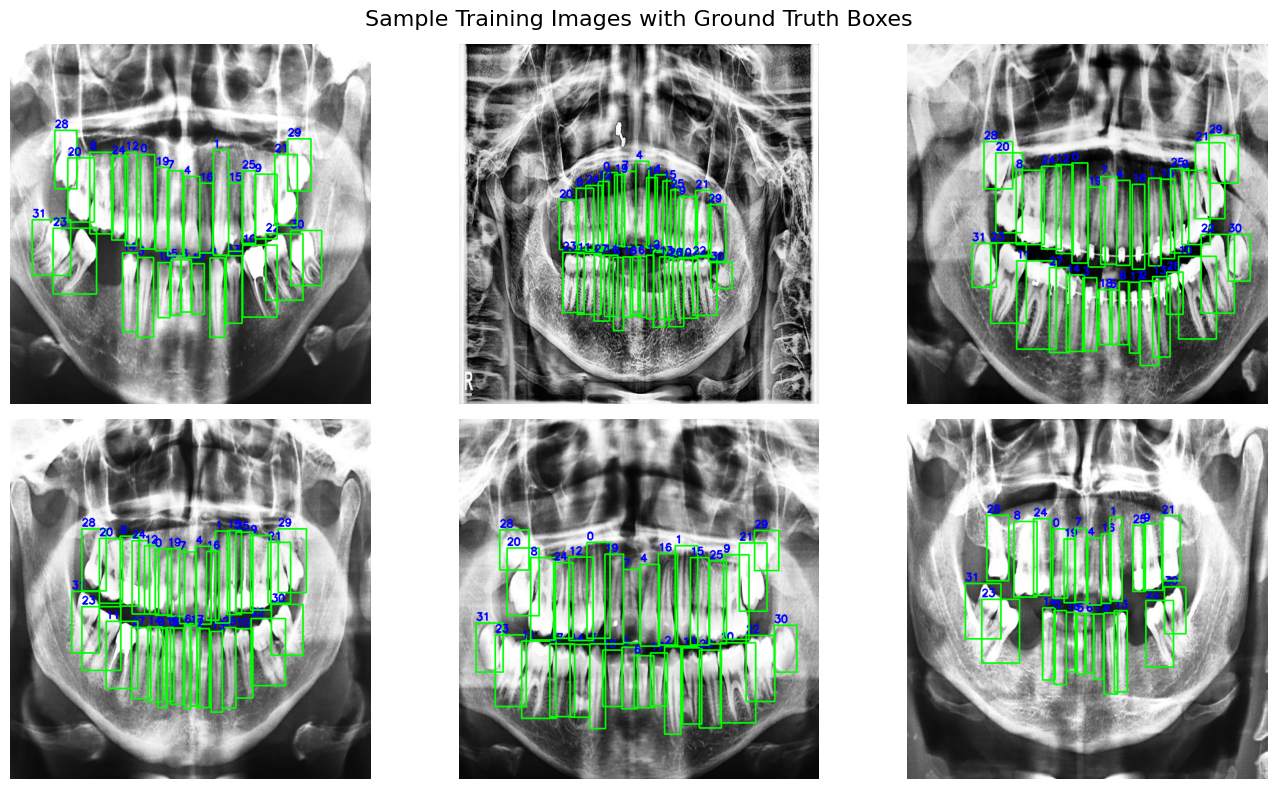

In [5]:
train_images_path = os.path.join(images_path, "train")
train_labels_path = os.path.join(labels_path, "train")

def visualize_samples(n=6):
    image_files = random.sample(os.listdir(train_images_path), n)

    plt.figure(figsize=(14,8))

    for i, img_name in enumerate(image_files):
        img_file = os.path.join(train_images_path, img_name)
        label_file = os.path.join(train_labels_path, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_file)
        h, w, _ = img.shape

        # Draw ground truth boxes
        if os.path.exists(label_file):
            with open(label_file) as f:
                for line in f:
                    cls, x, y, bw, bh = map(float, line.split())

                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                    cv2.putText(img, str(int(cls)), (x1, y1-5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle("Sample Training Images with Ground Truth Boxes", fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_samples()

## Class Distribution Analysis

The dataset contains annotations for 32 tooth classes. As shown in the distribution plot, most classes have a **comparable number of instances**, indicating that the dataset is generally well balanced.

Slightly lower instance counts are observed for some posterior tooth classes, which may influence detection performance for those categories. Overall, the balanced distribution supports stable model training, while visual challenges such as overlap, occlusion, and low contrast are expected to play a larger role in prediction errors.

✅ Classes found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
✅ Total classes: 32
✅ Max class id: 31


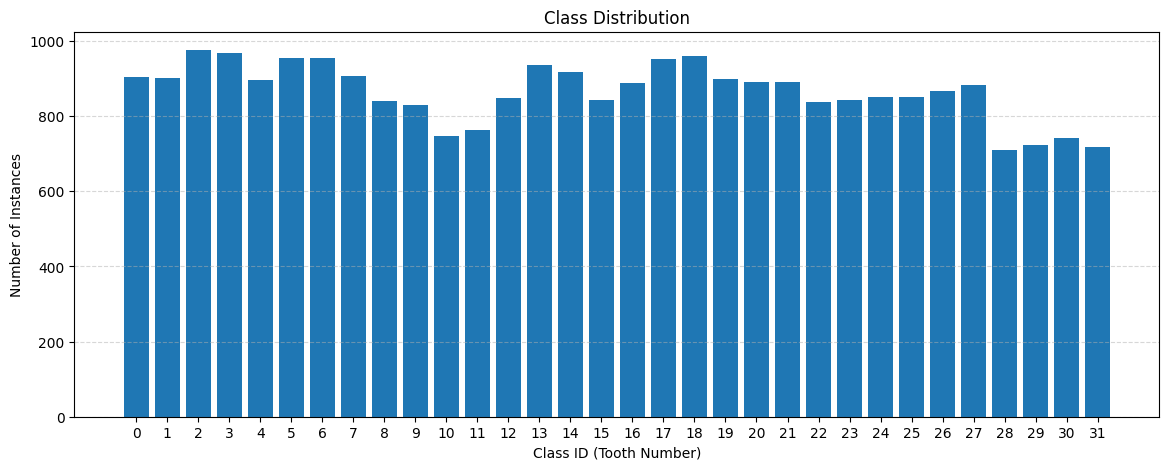

In [6]:
labels_dir = "/content/ToothNumber_TaskDataset/labels"

classes = set()
class_counts = Counter()

for root, dirs, files in os.walk(labels_dir):
    for file in files:
        if file.endswith(".txt"):
            path = os.path.join(root, file)

            with open(path, "r") as f:
                for line in f:
                    if line.strip():
                        class_id = int(line.split()[0])
                        classes.add(class_id)
                        class_counts[class_id] += 1

classes = sorted(list(classes))

print("✅ Classes found:", classes)
print("✅ Total classes:", len(classes))
print("✅ Max class id:", max(classes))


counts = [class_counts[c] for c in classes]


plt.figure(figsize=(14,5))
plt.bar(classes, counts)
plt.xlabel("Class ID (Tooth Number)")
plt.ylabel("Number of Instances")
plt.title("Class Distribution")
plt.xticks(classes)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Dataset Configuration (YOLO YAML)

To train the YOLO detection model, a dataset configuration file is created programmatically.  
This file defines the dataset path, train–validation split, and class names corresponding to tooth numbers.

In [7]:
num_classes = 32

yaml_text = f"""
path: /content/ToothNumber_TaskDataset
train: images/train
val: images/val

names:
"""

for i in range(num_classes):
    yaml_text += f"  {i}: tooth_{i}\n"

yaml_path = "/content/ToothNumber_TaskDataset/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("YAML created at:", yaml_path)

with open(yaml_path, "r") as f:
    print(f.read())

YAML created at: /content/ToothNumber_TaskDataset/data.yaml

path: /content/ToothNumber_TaskDataset
train: images/train
val: images/val

names:
  0: tooth_0
  1: tooth_1
  2: tooth_2
  3: tooth_3
  4: tooth_4
  5: tooth_5
  6: tooth_6
  7: tooth_7
  8: tooth_8
  9: tooth_9
  10: tooth_10
  11: tooth_11
  12: tooth_12
  13: tooth_13
  14: tooth_14
  15: tooth_15
  16: tooth_16
  17: tooth_17
  18: tooth_18
  19: tooth_19
  20: tooth_20
  21: tooth_21
  22: tooth_22
  23: tooth_23
  24: tooth_24
  25: tooth_25
  26: tooth_26
  27: tooth_27
  28: tooth_28
  29: tooth_29
  30: tooth_30
  31: tooth_31



## Hardware Setup

Before training, we verify GPU availability to ensure efficient model training and faster experimentation.

In [8]:
import torch

gpu_available = torch.cuda.is_available()

print("GPU Available:", gpu_available)

if gpu_available:
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Memory (GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9,2))
else:
    print("⚠️ Running on CPU")

GPU Available: True
GPU Name: Tesla T4
GPU Memory (GB): 15.64


## Model Choice

YOLO11m is selected because:

- Better feature extraction than YOLO11s
- Suitable for small object detection (teeth)
- Good speed-accuracy tradeoff

In [ ]:
!yolo detect train \
model=yolo11m.pt \
data=/content/ToothNumber_TaskDataset/data.yaml \
epochs=100 \
imgsz=768 \
batch=12 \
patience=20 \
cos_lr=True

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/ToothNumber_TaskDataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20,

## Training Metrics

The following plot shows the training and validation metrics over epochs, including box loss, classification loss, and mAP scores. These curves help assess model convergence and overall training stability.

In [ ]:
!unzip -q /content/runs.zip -d /content/runs

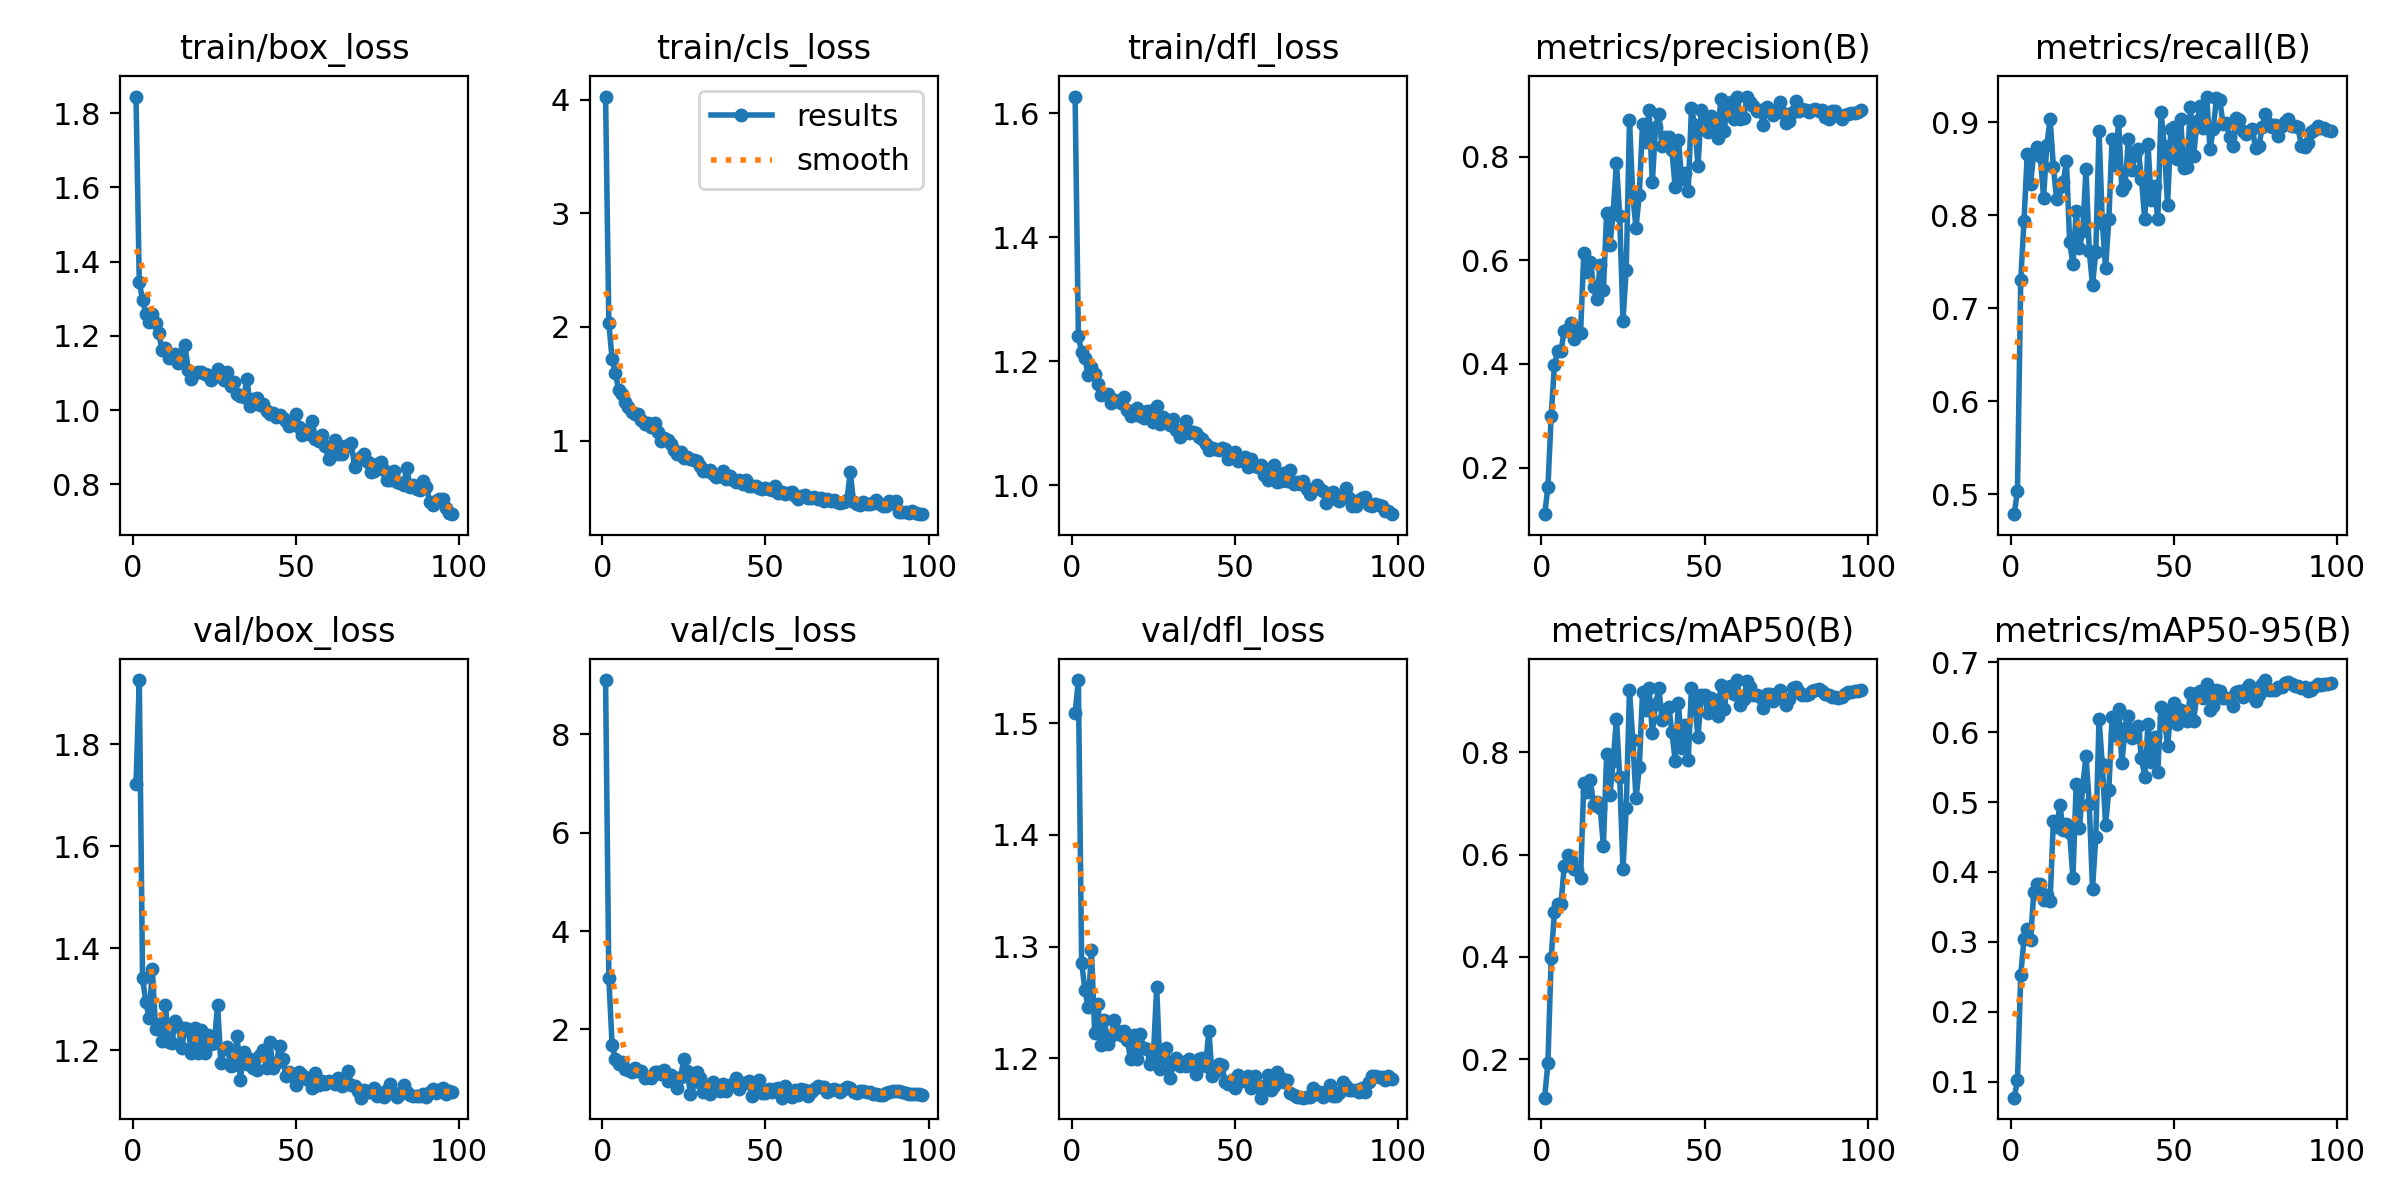

In [ ]:
results_path = "runs/detect/train/results.png"

if os.path.exists(results_path):
    display(Image(filename=results_path))
else:
    print("Training metrics graph not found. Check training run directory.")

### Observation

The training curves indicate steady reduction in loss values and consistent improvement in mAP across epochs, suggesting stable convergence. Minor fluctuations in later epochs may indicate the onset of overfitting, which is mitigated using early stopping.

## Validation Metrics

After training, the model is evaluated on the validation set to measure detection performance.  
Key metrics include Precision, Recall, mAP0.5, and mAP0.5:0.95, which reflect classification accuracy and bounding box localization quality.

In [10]:
model = YOLO("runs/detect/train/weights/best.pt")
metrics = model.val()
metrics

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,054,704 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.1 ms, read: 1302.7±653.4 MB/s, size: 89.6 KB)
val: Scanning /content/ToothNumber_TaskDataset/labels/val... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 2.1Kit/s 0.0s
val: New cache created: /content/ToothNumber_TaskDataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3s/it 9.0s
                   all        100       2746      0.986       0.99      0.991      0.829
               tooth_0         88         88      0.984      0.989      0.994      0.815
               tooth_1         90         90      0.978      0.981      0.982      0.823
               tooth_2         99         99          1      0.999      0.995      0.818
               tooth_3        100        100      0.98

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798016f4d9d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,


Overall Validation Metrics

Precision: 0.9858438367616071
Recall: 0.9899791389377024
mAP50: 0.9906691472827924
mAP50-95: 0.8290168135478243


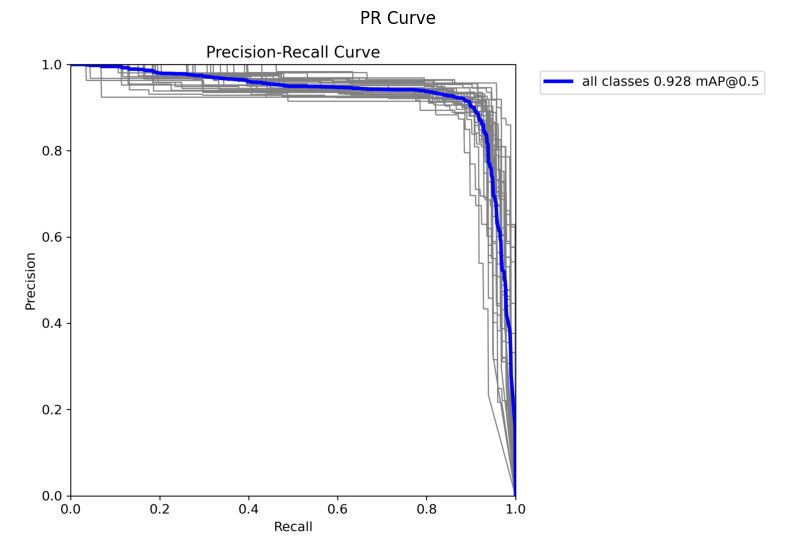

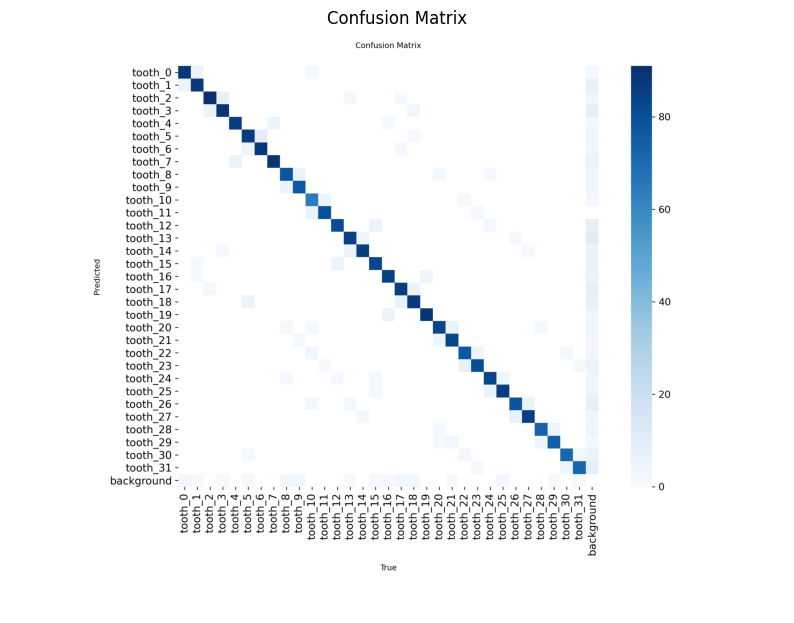

In [11]:
print("\nOverall Validation Metrics\n")

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)


pr_path = "runs/detect/train/BoxPR_curve.png"
cm_path = "runs/detect/train/confusion_matrix.png"

def show_image(path, title):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_image(pr_path, "PR Curve")
show_image(cm_path, "Confusion Matrix")

## Prediction Visualization / Inference

We visualize model predictions on random validation images to qualitatively assess detection performance, bounding box localization, and tooth numbering accuracy.


image 1/1 /content/ToothNumber_TaskDataset/images/val/cate2-00038_jpg.rf.2423b6801a5648d37ff9149efb311ab8.jpg: 768x768 1 tooth_0, 1 tooth_1, 1 tooth_2, 1 tooth_3, 1 tooth_4, 1 tooth_5, 1 tooth_6, 1 tooth_7, 1 tooth_8, 1 tooth_9, 1 tooth_10, 1 tooth_11, 1 tooth_12, 1 tooth_13, 1 tooth_14, 1 tooth_15, 1 tooth_16, 1 tooth_17, 1 tooth_18, 1 tooth_19, 1 tooth_20, 1 tooth_21, 1 tooth_22, 1 tooth_23, 1 tooth_24, 1 tooth_25, 1 tooth_26, 1 tooth_27, 1 tooth_28, 1 tooth_29, 1 tooth_30, 1 tooth_31, 2304.1ms
Speed: 17.4ms preprocess, 2304.1ms inference, 35.8ms postprocess per image at shape (1, 3, 768, 768)

image 1/1 /content/ToothNumber_TaskDataset/images/val/cate8-00191_jpg.rf.6a5a2a0a3cc8b967672423b048cfaabf.jpg: 768x768 1 tooth_2, 1 tooth_3, 1 tooth_6, 1 tooth_13, 1 tooth_17, 1 tooth_18, 1 tooth_26, 2073.7ms
Speed: 5.5ms preprocess, 2073.7ms inference, 1.2ms postprocess per image at shape (1, 3, 768, 768)

image 1/1 /content/ToothNumber_TaskDataset/images/val/cate8-00173_jpg.rf.7b0e3c8a22a80

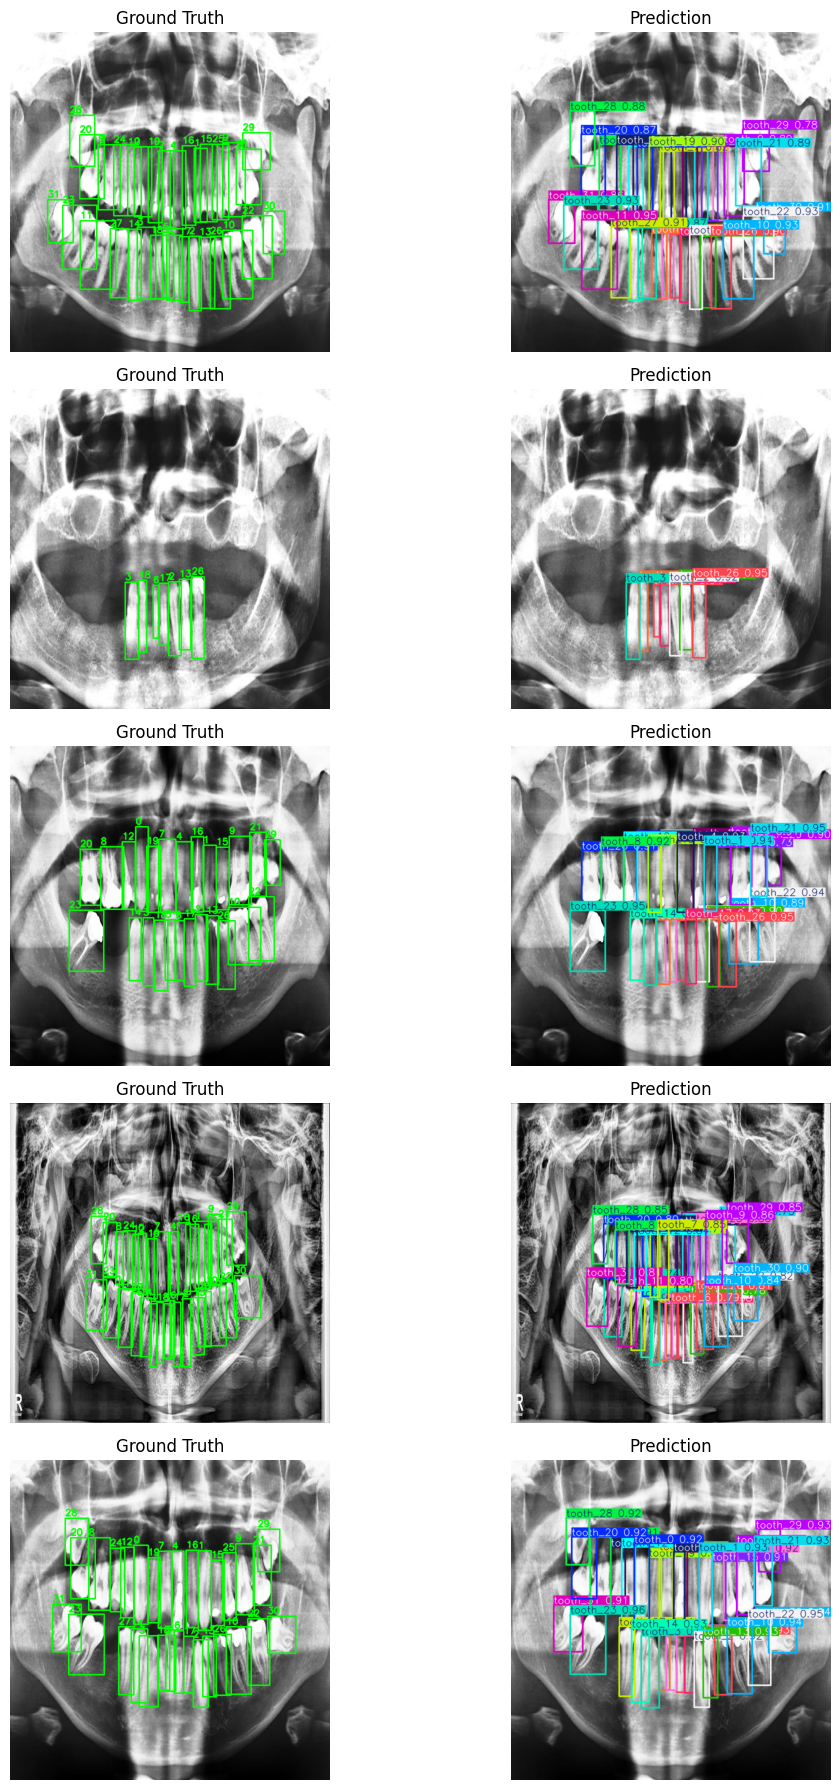

In [ ]:
MODEL_PATH = "/content/runs/detect/train/weights/best.pt"
VAL_IMAGES = "/content/ToothNumber_TaskDataset/images/val"
VAL_LABELS = "/content/ToothNumber_TaskDataset/labels/val"

model = YOLO(MODEL_PATH)

all_imgs = [f for f in os.listdir(VAL_IMAGES) if f.lower().endswith((".jpg",".png",".jpeg"))]

sample_imgs = random.sample(all_imgs, 5)

def draw_gt(img, label_path):

    h, w = img.shape[:2]

    if not os.path.exists(label_path):
        return img

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, bw, bh = map(float, line.split())

        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)

        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(img,str(int(cls)),(x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

    return img


plt.figure(figsize=(12,18))

for i,img_name in enumerate(sample_imgs):

    img_path = os.path.join(VAL_IMAGES,img_name)
    label_path = os.path.join(VAL_LABELS,img_name.replace(".jpg",".txt"))

    img = cv2.imread(img_path)


    results = model(img_path, conf=0.25)[0]
    pred_img = results.plot()


    gt_img = draw_gt(img.copy(), label_path)


    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)


    plt.subplot(5,2,2*i+1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5,2,2*i+2)
    plt.imshow(pred_img)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Error Analysis

To better understand model limitations, we analyze validation images where detections may be incomplete or uncertain.  
This helps identify common failure patterns and potential areas for improvement.

In [ ]:
failure_images = []

val_labels_path = os.path.join(labels_path, "val")

for img_name in os.listdir(val_images_path):
    img_path = os.path.join(val_images_path, img_name)
    label_path = os.path.join(val_labels_path, img_name.replace(".jpg",".txt"))

    # GT count
    if os.path.exists(label_path):
        with open(label_path) as f:
            gt_count = len([l for l in f.readlines() if l.strip()])
    else:
        gt_count = 0

    # prediction count
    result = model.predict(img_path, conf=0.25, verbose=False)[0]
    pred_count = len(result.boxes)

    # flag mismatch
    if abs(gt_count - pred_count) >= 3:
        failure_images.append(img_name)

print("Potential mismatched detection images:", len(failure_images))
failure_images[:10]

Potential mismatched detection images: 4


['cate6-00075_jpg.rf.ca4afe79ad1594b3fb8c3c41a72cfb10.jpg',
 'cate8-00253_jpg.rf.ea84a9f38e3dfb75aeda9c55b636661b.jpg',
 'cate7-00033_jpg.rf.9927f64df67790b3567ca5a703c8d8ee.jpg',
 'cate8-00296_jpg.rf.95e9e4fa74799d3cdc335c02e04d23bf.jpg']

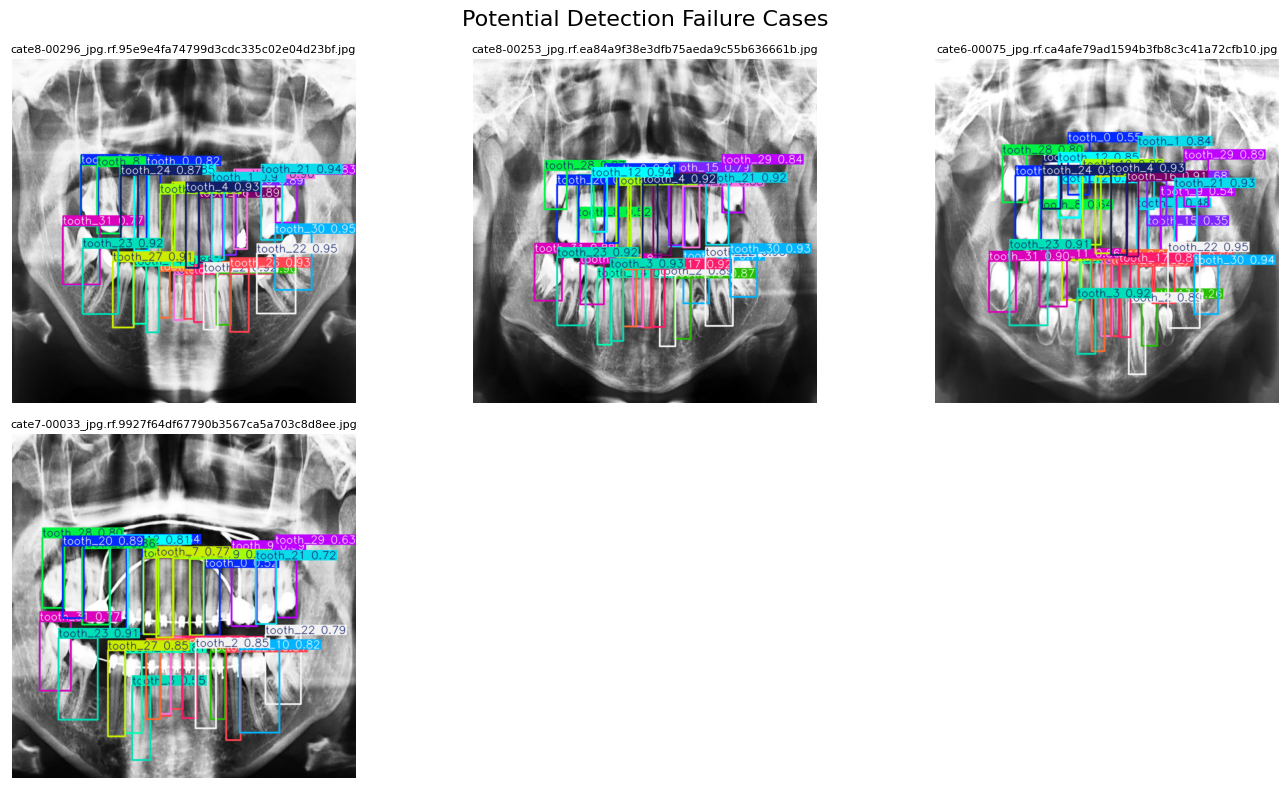

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

def show_failure_images(n=6):
    if len(failure_images) == 0:
        print("No failure images found")
        return

    imgs = random.sample(failure_images, min(n, len(failure_images)))

    plt.figure(figsize=(14,8))

    for i, img_name in enumerate(imgs):
        img_path = os.path.join(val_images_path, img_name)

        result = model.predict(img_path, conf=0.25, verbose=False)[0]
        plotted = result.plot()

        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(plotted)
        plt.title(img_name, fontsize=8)
        plt.axis("off")

    plt.suptitle("Potential Detection Failure Cases", fontsize=16)
    plt.tight_layout()
    plt.show()

show_failure_images()

## Inference Speed Test

We measure the model’s inference time on validation images to evaluate real-time feasibility.  
Speed is an important factor for clinical deployment scenarios where fast and reliable detection is required.

In [13]:
import time
import random

val_images_path = "/content/ToothNumber_TaskDataset/images/val"

test_imgs = random.sample(os.listdir(val_images_path), 20)

times = []

for img_name in test_imgs:
    img_path = os.path.join(val_images_path, img_name)

    start = time.time()
    model.predict(img_path, conf=0.25, verbose=False)
    end = time.time()

    times.append(end - start)

avg_time = sum(times) / len(times)
fps = 1 / avg_time

print(f"Average Inference Time per Image: {avg_time:.4f} sec")
print(f"Approx FPS: {fps:.2f}")

Average Inference Time per Image: 0.0450 sec
Approx FPS: 22.21


## Conclusion

- Achieved mAP50 ≈ 0.92 and mAP50-95 ≈ 0.63
- Model performs well across most tooth classes
- Some failure cases observed in occluded and blurred images

Future improvements:
- Higher resolution training
- Segmentation-based approach
- Class-balanced sampling